✅ Библиотеки загружены
✅ Данные загружены. Записей: 146
Период: с 2014-01-31 00:00:00 по 2026-02-28 00:00:00

3. ПОЧЕМУ SARIMA, А НЕ PROPHET

📌 КЛЮЧЕВАЯ ПРОБЛЕМА: АВТОКОРРЕЛЯЦИЯ ОСТАТКОВ 4-ГО ПОРЯДКА

Во всех предыдущих моделях (базовая Ridge, полная модель с 38 признаками)
диагностика остатков на обучающей выборке выявила значимую автокорреляцию
4-го порядка (тест Бройша-Годфри, p < 0.05).

Это означает, что ошибки модели коррелируют с ошибками 4 месяца назад,
что указывает на неучтенную квартальную (сезонную) структуру.

ПОЧЕМУ НЕ PROPHET:
- Prophet моделирует сезонность через ряды Фурье
- Не учитывает автокорреляцию в остатках напрямую
- При автокоррелированных ошибках дает смещенные прогнозы

ПОЧЕМУ SARIMA:
- Явно моделирует автокорреляцию через AR/MA компоненты
- Сезонные компоненты (P,D,Q,s) могут учесть квартальную структуру
- Ljung-Box тест позволяет проверить, устранена ли автокорреляция

ВЫВОД: Выбираем SARIMA для решения проблемы автокорреляции.


4. АНАЛИЗ СТАЦИОНАРНОСТИ

🔍

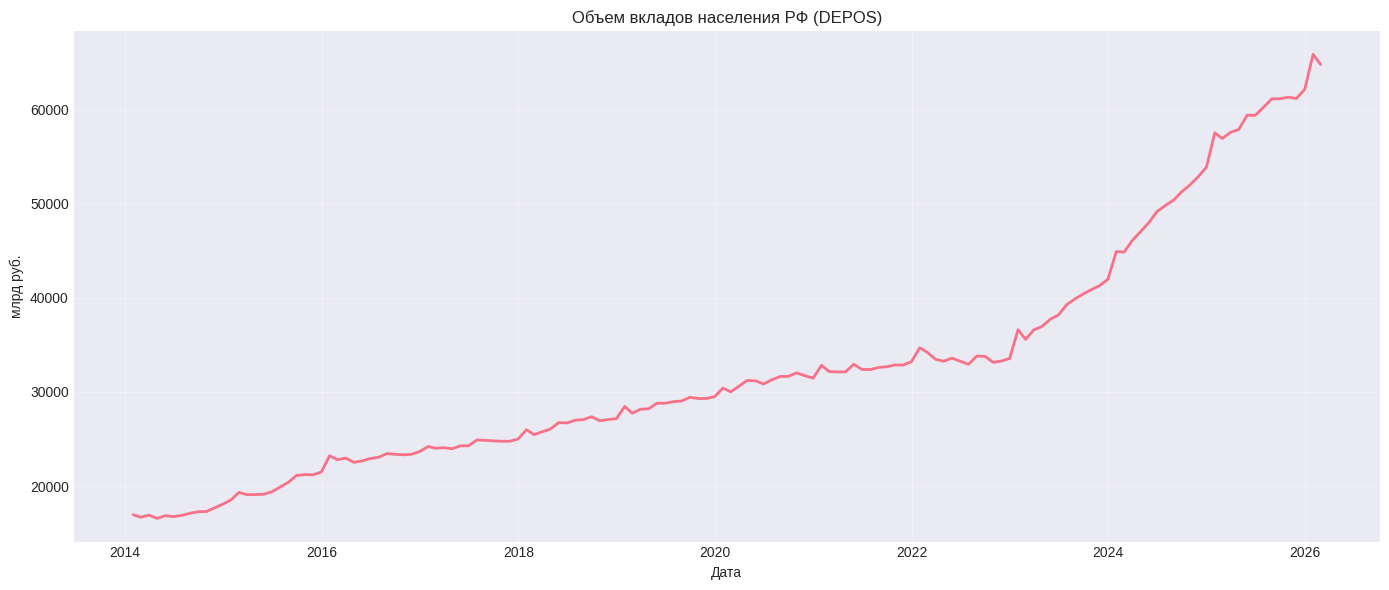


5. ОПРЕДЕЛЕНИЕ ПОРЯДКА ДИФФЕРЕНЦИРОВАНИЯ (d)


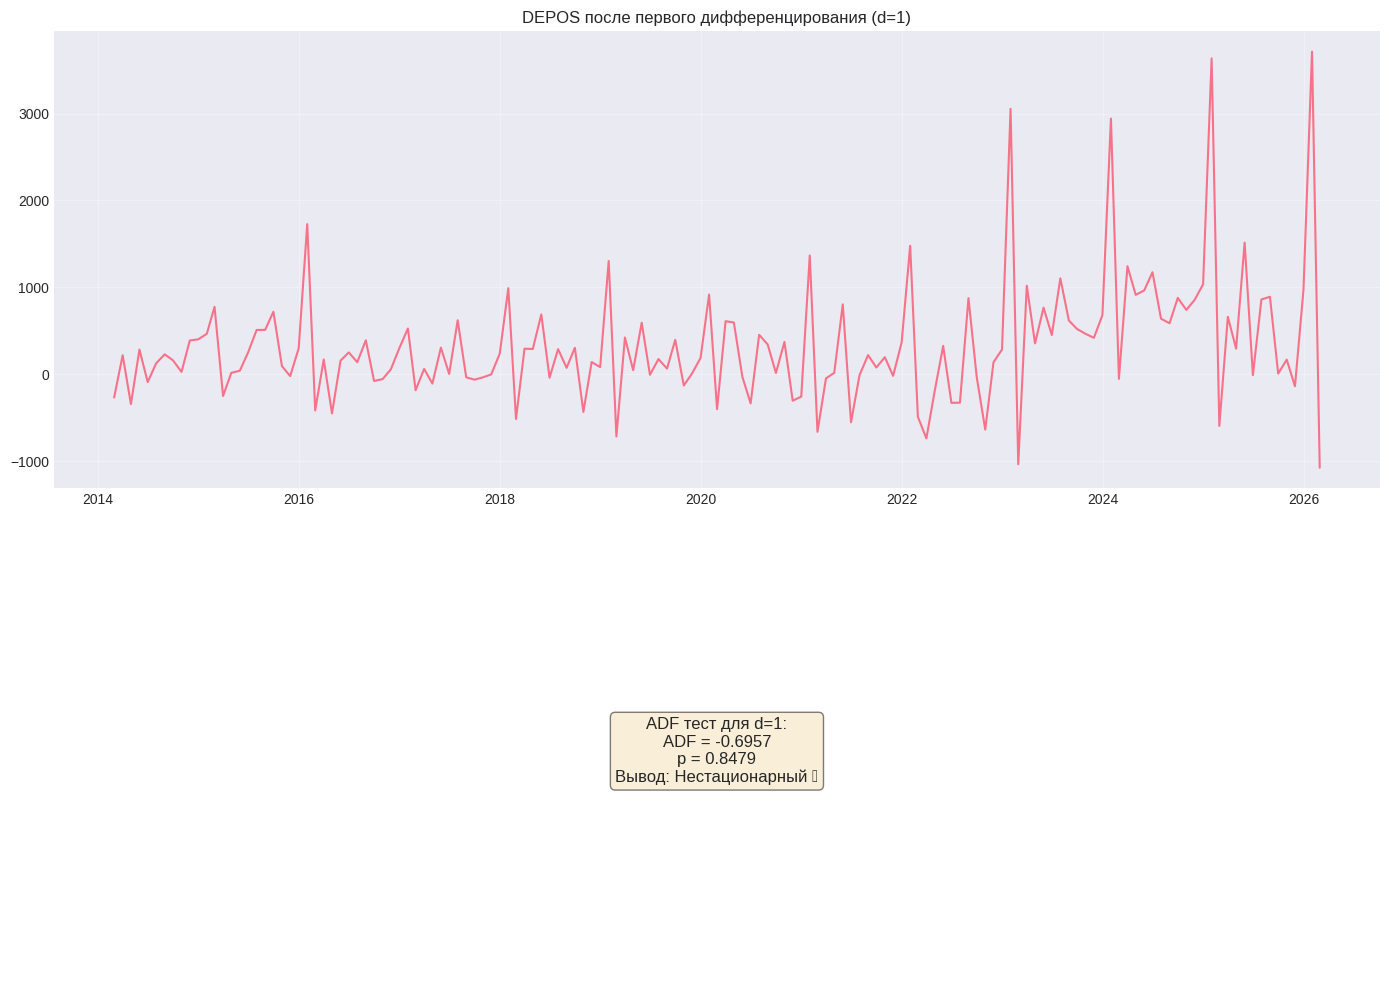


📊 Результаты:
   ADF после d=1: -0.6957, p = 0.8479
   → Требуется d=2

✅ Блок 5 начат: SARIMA выбран, стационарность проанализирована
📌 Продолжение: подбор параметров SARIMA (p,d,q)(P,D,Q,s)


In [1]:
# ============================================================
# БЛОК 5: МОДЕЛИ ВРЕМЕННЫХ РЯДОВ (SARIMA)
# Проект: Прогнозирование объема вкладов населения РФ
# Автор: Надежда Силкина
# Дата: 2026
# ============================================================

# ============================================================
# 1. ПОДКЛЮЧЕНИЕ БИБЛИОТЕК
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Библиотеки загружены")

# ============================================================
# 2. ЗАГРУЗКА ДАННЫХ
# ============================================================

url = 'https://raw.githubusercontent.com/HopeSilkina/deposits_forecast_project/main/data/processed_deposits_data.xlsx'
df = pd.read_excel(url, sheet_name='data')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f"✅ Данные загружены. Записей: {len(df)}")
print(f"Период: с {df.index.min()} по {df.index.max()}")

# ============================================================
# 3. МЕТОДОЛОГИЧЕСКОЕ ОБОСНОВАНИЕ ВЫБОРА SARIMA
# ============================================================

print("\n" + "="*60)
print("3. ПОЧЕМУ SARIMA, А НЕ PROPHET")
print("="*60)

print("""
📌 КЛЮЧЕВАЯ ПРОБЛЕМА: АВТОКОРРЕЛЯЦИЯ ОСТАТКОВ 4-ГО ПОРЯДКА

Во всех предыдущих моделях (базовая Ridge, полная модель с 38 признаками)
диагностика остатков на обучающей выборке выявила значимую автокорреляцию
4-го порядка (тест Бройша-Годфри, p < 0.05).

Это означает, что ошибки модели коррелируют с ошибками 4 месяца назад,
что указывает на неучтенную квартальную (сезонную) структуру.

ПОЧЕМУ НЕ PROPHET:
- Prophet моделирует сезонность через ряды Фурье
- Не учитывает автокорреляцию в остатках напрямую
- При автокоррелированных ошибках дает смещенные прогнозы

ПОЧЕМУ SARIMA:
- Явно моделирует автокорреляцию через AR/MA компоненты
- Сезонные компоненты (P,D,Q,s) могут учесть квартальную структуру
- Ljung-Box тест позволяет проверить, устранена ли автокорреляция

ВЫВОД: Выбираем SARIMA для решения проблемы автокорреляции.
""")

# ============================================================
# 4. АНАЛИЗ СТАЦИОНАРНОСТИ
# ============================================================

print("\n" + "="*60)
print("4. АНАЛИЗ СТАЦИОНАРНОСТИ")
print("="*60)

# 4.1. Тест ADF
print("\n🔍 Тест Дики-Фуллера (ADF):")
adf_result = adfuller(df['DEPOS'], autolag='AIC')
print(f"   ADF-статистика: {adf_result[0]:.4f}")
print(f"   p-значение: {adf_result[1]:.4f}")
print(f"   Вывод: {'Стационарный ✅' if adf_result[1] < 0.05 else 'Нестационарный ❌'}")

# 4.2. Тест KPSS
print("\n🔍 Тест KPSS:")
kpss_result = kpss(df['DEPOS'], regression='ct')
print(f"   KPSS-статистика: {kpss_result[0]:.4f}")
print(f"   p-значение: {kpss_result[1]:.4f}")
print(f"   Вывод: {'Стационарный ✅' if kpss_result[1] > 0.05 else 'Нестационарный ❌'}")

# 4.3. График ряда
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['DEPOS'], linewidth=2)
plt.title('Объем вкладов населения РФ (DEPOS)')
plt.xlabel('Дата')
plt.ylabel('млрд руб.')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_depos_series.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. ОПРЕДЕЛЕНИЕ ПОРЯДКА ДИФФЕРЕНЦИРОВАНИЯ
# ============================================================

print("\n" + "="*60)
print("5. ОПРЕДЕЛЕНИЕ ПОРЯДКА ДИФФЕРЕНЦИРОВАНИЯ (d)")
print("="*60)

# Первое дифференцирование
df['DEPOS_diff1'] = df['DEPOS'].diff()

# График после первого дифференцирования
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(df.index, df['DEPOS_diff1'], linewidth=1.5)
axes[0].set_title('DEPOS после первого дифференцирования (d=1)')
axes[0].grid(True, alpha=0.3)

# ADF тест для diff1
adf_diff1 = adfuller(df['DEPOS_diff1'].dropna(), autolag='AIC')
axes[1].text(0.5, 0.5,
             f'ADF тест для d=1:\nADF = {adf_diff1[0]:.4f}\np = {adf_diff1[1]:.4f}\nВывод: {"Стационарный ✅" if adf_diff1[1] < 0.05 else "Нестационарный ❌"}',
             transform=axes[1].transAxes, fontsize=12, ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].axis('off')

plt.tight_layout()
plt.savefig('05_diff1_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Результаты:")
print(f"   ADF после d=1: {adf_diff1[0]:.4f}, p = {adf_diff1[1]:.4f}")
print(f"   → {'Ряд стационарен, d=1 достаточно' if adf_diff1[1] < 0.05 else 'Требуется d=2'}")

print("\n✅ Блок 5 начат: SARIMA выбран, стационарность проанализирована")
print("📌 Продолжение: подбор параметров SARIMA (p,d,q)(P,D,Q,s)")